# Norway EV residential charging reports: focused source audit and EDA

The four CSVs are documented by Sørensen et al., *Data in Brief* 57 (2024),
110883 ([DOI](https://doi.org/10.1016/j.dib.2024.110883)); the supplied paper is
`data/raw/norway_ev/docs/1-s2.0-S2352340924008461-main.pdf` (Tables 1–5,
pp. 3–7). This notebook reads the raw files and regenerates the three figures.
It uses **residential charging records** to describe plug-in/plug-out behaviour,
delivered energy, connection time, and user variation. The NHTS work is unchanged.

The source files use semicolons and comma decimals. Times are supplied as local
CET with daylight saving time (paper p. 3); we show local clock times, and use
the report's `connection_time` for duration instead of inventing timezone-aware
timestamps. The data have no survey weights, so percentages are of recorded
sessions, not Norway's national EV population.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

root = Path.cwd().resolve()
if not (root / "data" / "raw" / "norway_ev").exists():
    root = root.parent
raw = root / "data" / "raw" / "norway_ev"
figures = root / "outputs" / "figures" / "norway_ev"
figures.mkdir(parents=True, exist_ok=True)
files = {
    "D1 original reports":"Dataset1_charging_reports.csv",
    "D2 user predictions":"Dataset2_user_predictions.csv",
    "D3 session predictions":"Dataset3_session_predictions.csv",
    "D4 hourly predictions":"Dataset4_hourly_predictions.csv",
}
tables = {label: pd.read_csv(raw / filename, sep=";", decimal=",",
                             dtype={"location":"string", "user_id":"string", "session_id":"string"},
                             low_memory=False)
          for label, filename in files.items()}
d1, d2, d3, d4 = tables.values()

plt.rcParams.update({"font.size":11, "axes.spines.top":False,
                     "axes.spines.right":False, "figure.facecolor":"white"})
BLUE, ORANGE, GREEN, GREY = "#2463a6", "#d97732", "#287d69", "#697a89"
def save_show(fig, filename):
    fig.tight_layout()
    path = figures / filename
    fig.savefig(path, dpi=190, bbox_inches="tight")
    plt.show()
    return path

def describe_quantity(series, unit):
    x = pd.to_numeric(series, errors="coerce").dropna()
    return pd.Series({"n":len(x), "unit":unit, "mean":x.mean(), "p25":x.quantile(.25),
                      "median":x.median(), "p75":x.quantile(.75), "p90":x.quantile(.9)})



## 1. Four tables and their observation units

The source paper's Tables 1–4 define the fields below. “Original report” means
charge-point operator/housing-cooperative data, **not** vehicle battery telemetry.
`connection_time` is calculated from the reported connection interval. Dataset
2–4 values were constructed by the authors' methods; they are not instrument
measurements. Table 2 prints battery capacity in kW, but the paper's equation
divides energy by an SoC fraction, giving kWh; we use kWh as the physical unit.

| Table | One row | Field meanings and provenance |
|---|---|---|
| D1 original reports | One charging session; unique `session_id`, repeated `user_id`, residential `location` | `plugin_time`, `plugout_time`: original event timestamps; `energy_session`: original delivered energy (kWh); `connection_time`: calculated connection duration (h). |
| D2 user predictions | One user; unique `user_id` | `charging_power`: **inferred** user charging power (kW); `battery_capacity`: **inferred** net capacity (kWh), using 88% efficiency and assumed SoC range. |
| D3 session predictions | One predicted session; unique `session_id` | `charging_time`: calculated energy / inferred power (h); `idle_time`: connection minus calculated charge time (h); `SoC_diff`, `SoC_start`: inferred percentages, latter assumes 95% end SoC; `idle_session`: inferred idle energy capacity (kWh); `non_flex_session`: reported energy (kWh) copied only when inferred idle time <1 h. |
| D4 hourly predictions | One modeled hour of a session, keyed by `session_id` + `date_from` where IDs exist | `energy_charged_i`, `energy_idle_i`, `energy_connected_i`: modeled kWh during that hour; `SoC_diff_i`, `SoC_from_i`, `SoC_to_i`: modeled SoC percentages. These use immediate post-plug-in charging and constant inferred user power, not hourly meter traces. |

In [2]:
overview = pd.DataFrame([
    {"Table":label, "Rows":len(frame), "Columns":frame.shape[1],
     "Users":frame.user_id.nunique(),
     "Unique session IDs":frame.session_id.nunique() if "session_id" in frame else "—",
     "Observation unit":unit}
    for (label,frame),unit in zip(tables.items(),[
        "Reported charging session", "User prediction", "Session prediction", "Modeled session-hour"])
])
display(overview)
missing = pd.concat({label: frame.isna().sum() for label,frame in tables.items()},
                    names=["Table","Column"]).rename("missing rows").reset_index()
display(missing.loc[missing["missing rows"].gt(0)].sort_values(["Table","missing rows"],
    ascending=[True,False]).reset_index(drop=True))
display(Markdown(
    "**Missing-value conventions.** CSV blanks load as NA. In D1, 38 rows have no "
    "plug-out/connection duration, so their delivered energy remains usable but "
    "their end-time and duration do not. In D3, 179 charging/idle times are blank "
    "under the paper's rule for infeasible inferred duration. Blank `non_flex_session` "
    "mainly means the modeled <1 h idle condition does not apply. In D4, blank "
    "charged/idle-hour fields mark hours without that modeled component; they "
    "should not be read as missing charger telemetry."
))



,Table,Rows,Columns,Users,Unique session IDs,Observation unit
0,D1 original reports,35377,7,267,35377,Reported charging session
1,D2 user predictions,267,3,267,—,User prediction
2,D3 session predictions,34537,8,261,34537,Session prediction
3,D4 hourly predictions,469897,9,261,34537,Modeled session-hour


,Table,Column,missing rows
0,D1 original reports,plugout_time,38
1,D1 original reports,connection_time,38
2,D2 user predictions,charging_power,6
3,D2 user predictions,battery_capacity,6
4,D3 session predictions,non_flex_session,26041
5,D3 session predictions,charging_time,179
6,D3 session predictions,idle_time,179
7,D3 session predictions,idle_session,179
8,D4 hourly predictions,energy_charged_i,344224
9,D4 hourly predictions,energy_idle_i,98094


**Missing-value conventions.** CSV blanks load as NA. In D1, 38 rows have no plug-out/connection duration, so their delivered energy remains usable but their end-time and duration do not. In D3, 179 charging/idle times are blank under the paper's rule for infeasible inferred duration. Blank `non_flex_session` mainly means the modeled <1 h idle condition does not apply. In D4, blank charged/idle-hour fields mark hours without that modeled component; they should not be read as missing charger telemetry.

## 2. Keys, joins, and an audit of supplied time fields

D1 → D2 is many sessions to one user. D3 joins one-to-one to the covered D1
sessions by `session_id`; `user_id` must agree. D4 joins many hour rows to one
D3 session using `session_id` (and `user_id` as a check); `date_from` is the
within-session hour coordinate. D4 also contains rows with blank IDs. We audit
these separately and do not interpret them as identifiable user sessions.

In [3]:
assert d1.session_id.is_unique and d2.user_id.is_unique and d3.session_id.is_unique
d3_check = d3[["session_id","user_id"]].merge(
    d1[["session_id","user_id"]], on="session_id", how="left",
    suffixes=("_d3","_d1"), validate="one_to_one", indicator=True)
d4_identified = d4.loc[d4.session_id.notna()].copy()
assert not d4_identified[["session_id","date_from"]].duplicated().any()
assert set(d4_identified.session_id).issubset(set(d3.session_id))
assert not d3_check.user_id_d3.ne(d3_check.user_id_d1).fillna(True).any()
assert d3_check._merge.eq("both").all()
assert set(d3.user_id).issubset(set(d2.user_id))
d4_user_check = d4_identified[["session_id","user_id"]].drop_duplicates().merge(
    d3[["session_id","user_id"]], on="session_id", suffixes=("_d4","_d3"),
    validate="one_to_one")
assert len(d4_user_check)==d3.session_id.nunique()
assert not d4_user_check.user_id_d4.ne(d4_user_check.user_id_d3).fillna(True).any()
unidentified_hourly = d4.loc[d4.session_id.isna()]
unpredicted_sessions = d1.loc[~d1.session_id.isin(d3.session_id)]
display(pd.Series({
    "D1 unique sessions":d1.session_id.nunique(),
    "D2 unique users":d2.user_id.nunique(),
    "D2 users with predicted power and capacity":int(d2[["charging_power","battery_capacity"]].notna().all(axis=1).sum()),
    "D3 sessions matched to D1":len(d3_check),
    "D1 sessions without D3 prediction":len(d1)-len(d3),
    "D1 users represented only by unpredicted sessions":unpredicted_sessions.user_id.nunique(),
    "D4 identified session-hour rows":len(d4_identified),
    "D4 identified sessions":d4_identified.session_id.nunique(),
    "D4 rows without a user/session ID":len(unidentified_hourly),
    "D4 unidentified rows with nonzero connected capacity":int(unidentified_hourly.energy_connected_i.fillna(0).ne(0).sum()),
},name="Relationship audit"))

d1["plugin_dt"] = pd.to_datetime(d1.plugin_time, errors="coerce")
d1["plugout_dt"] = pd.to_datetime(d1.plugout_time, errors="coerce")
d1["wall_clock_hours"] = (d1.plugout_dt-d1.plugin_dt).dt.total_seconds()/3600
d1["duration_difference_h"] = d1.wall_clock_hours-d1.connection_time
complete = d1.loc[d1.plugin_dt.notna() & d1.plugout_dt.notna() &
                  d1.connection_time.gt(0) & d1.energy_session.ge(0)].copy()
complete["average_connection_kw"] = complete.energy_session/complete.connection_time
display(pd.Series({
    "D1 unparseable plug-in timestamps":int(d1.plugin_dt.isna().sum()),
    "D1 missing/unparseable plug-out timestamps":int(d1.plugout_dt.isna().sum()),
    "D1 nonpositive recorded energy":int(d1.energy_session.le(0).sum()),
    "D1 recorded energy <=0.5 kWh":int(d1.energy_session.le(.5).sum()),
    "D1 complete timed sessions":len(complete),
    "supplied duration differs from naive wall-clock gap by >5 min":int(d1.duration_difference_h.abs().gt(5/60).sum()),
    "largest absolute duration difference (h)":round(d1.duration_difference_h.abs().max(),2),
},name="D1 audit"))
display(Markdown(
    "The paper says the supplied times have daylight-saving corrections. We use "
    "the original `connection_time` for duration. Local timestamps are used only "
    "for time-of-day and ordering; the wall-clock discrepancy audit above is not "
    "silently reconciled. The paper already cleaned the reports, so remaining "
    "small-energy records are shown rather than re-filtered. The 439 reports at "
    "or below 0.5 kWh remain in this release despite the paper's listed cleaning "
    "criterion; their provenance cannot be resolved from these files alone."
))



D1 unique sessions                                       35377
D2 unique users                                            267
D2 users with predicted power and capacity                 261
D3 sessions matched to D1                                34537
D1 sessions without D3 prediction                          840
D1 users represented only by unpredicted sessions            6
D4 identified session-hour rows                         463187
D4 identified sessions                                   34537
D4 rows without a user/session ID                         6710
D4 unidentified rows with nonzero connected capacity         0
Name: Relationship audit, dtype: int64

D1 unparseable plug-in timestamps                                    0.0
D1 missing/unparseable plug-out timestamps                          38.0
D1 nonpositive recorded energy                                       0.0
D1 recorded energy <=0.5 kWh                                       439.0
D1 complete timed sessions                                       35339.0
supplied duration differs from naive wall-clock gap by >5 min       26.0
largest absolute duration difference (h)                             2.0
Name: D1 audit, dtype: float64

The paper says the supplied times have daylight-saving corrections. We use the original `connection_time` for duration. Local timestamps are used only for time-of-day and ordering; the wall-clock discrepancy audit above is not silently reconciled. The paper already cleaned the reports, so remaining small-energy records are shown rather than re-filtered. The 439 reports at or below 0.5 kWh remain in this release despite the paper's listed cleaning criterion; their provenance cannot be resolved from these files alone.

## 3. Observed session timing

Each curve is the share of **its own available reports** in a 30-minute local
clock bin. Plug-in has all 35,377 records; plug-out lacks the 38 unreported ends.
These are residential connection events, not vehicle arrivals at every home.

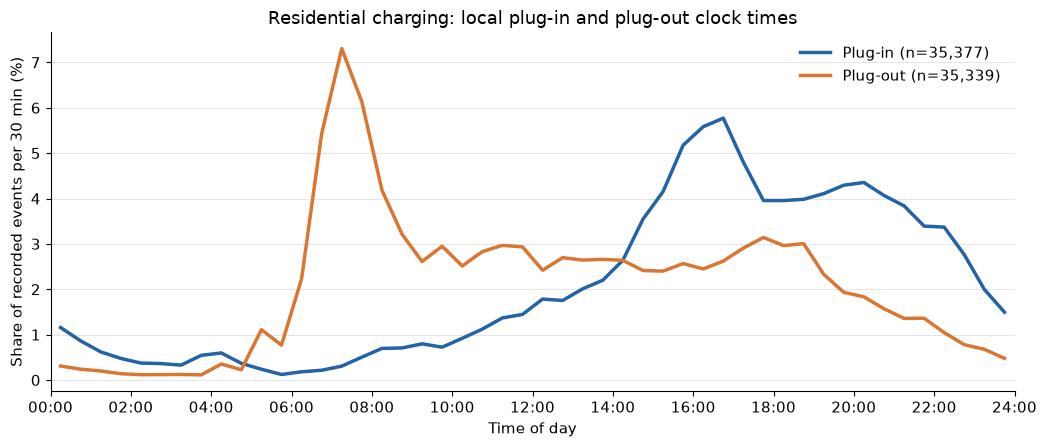

- **Observed:** 52.1% of plug-ins are from 16:00 to 21:59; 34.1% of known plug-outs are from 06:00 to 09:59.
- **Observed:** 59.7% of complete sessions cross a local calendar-day boundary. This residential timing can later check a home-charging schedule, but it does not tell us whether every home arrival becomes a charge.

In [4]:
bins = np.arange(0, 1441, 30)
centers = (bins[:-1]+bins[1:])/2
plugin_min = d1.plugin_dt.dt.hour*60+d1.plugin_dt.dt.minute
plugout_min = d1.plugout_dt.dt.hour*60+d1.plugout_dt.dt.minute
def shares(clock_minutes):
    x = clock_minutes.dropna().to_numpy(dtype=float)
    return 100*np.histogram(x,bins=bins)[0]/len(x)
plugin_share, plugout_share = shares(plugin_min), shares(plugout_min)
fig,ax = plt.subplots(figsize=(10.6,4.6))
ax.plot(centers,plugin_share,lw=2.5,color=BLUE,label=f"Plug-in (n={plugin_min.notna().sum():,})")
ax.plot(centers,plugout_share,lw=2.5,color=ORANGE,label=f"Plug-out (n={plugout_min.notna().sum():,})")
ax.set_xticks(np.arange(0,1441,120),[f"{h:02d}:00" if h<24 else "24:00" for h in range(0,25,2)])
ax.set_xlim(0,1440)
ax.set(title="Residential charging: local plug-in and plug-out clock times",
       xlabel="Time of day",ylabel="Share of recorded events per 30 min (%)")
ax.grid(axis="y",color="#e1e6eb",lw=.7)
ax.legend(frameon=False)
fig_time=save_show(fig,"01_plugin_plugout_clock.png")
plugin_evening = 100*d1.plugin_dt.dt.hour.between(16,21).mean()
plugout_morning = 100*d1.plugout_dt.dt.hour.between(6,9).sum()/d1.plugout_dt.notna().sum()
overnight = 100*(complete.plugout_dt.dt.date>complete.plugin_dt.dt.date).mean()
display(Markdown(
    f"- **Observed:** {plugin_evening:.1f}% of plug-ins are from 16:00 to 21:59; "
    f"{plugout_morning:.1f}% of known plug-outs are from 06:00 to 09:59.\n"
    f"- **Observed:** {overnight:.1f}% of complete sessions cross a local calendar-day boundary. "
    "This residential timing can later check a home-charging schedule, but it "
    "does not tell us whether every home arrival becomes a charge."
))



## 4. Delivered energy and connection duration

`energy_session` is reported energy delivered at the charging point (kWh),
available for every session. `connection_time` is calculated from the original
connection report (hours) and missing for 38 sessions. Both distributions use
all available values for their statistics; plots show the first 99% of each
range to keep the central shape legible. The right tail remains in calculations.

,n,unit,mean,p25,median,p75,p90
Energy delivered per session,35377,kWh,12.656105,5.16,9.03,16.42,26.764
Connection duration,35339,h,12.658947,3.45,11.19778,15.90611,22.13333
Average delivered power over whole connection,35339,kW,1.946759,0.542577,1.288665,3.008551,3.690064


The average-power row is **calculated** as reported delivered kWh divided by reported connection hours. It includes idle connected time, so it is neither measured instantaneous charging power nor the authors' predicted vehicle/charger power.

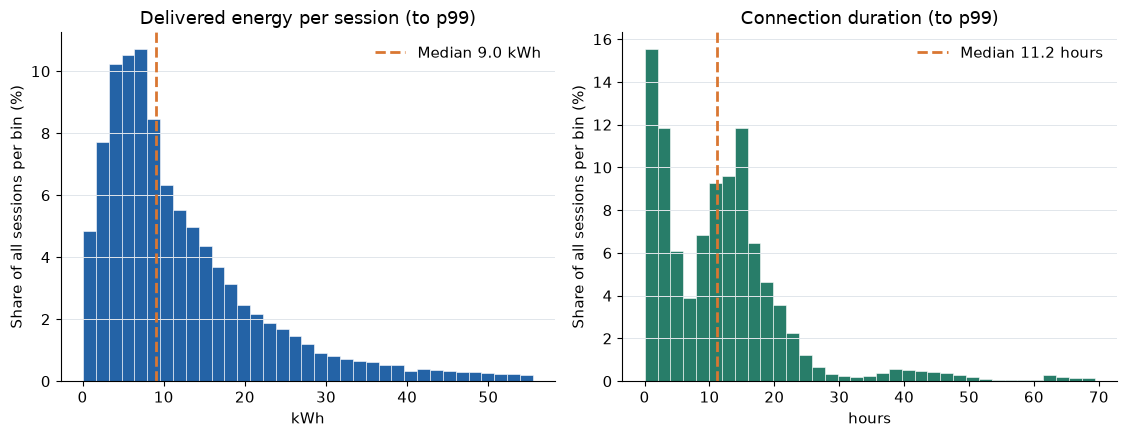

- **Observed:** median delivered energy is **9.0 kWh** (p25–p75 5.2–16.4); median connection is **11.2 h**.
- **Possible later use:** compare residential model outputs against these session-level quantities. Connection time alone does not measure active charging.

In [5]:
observed_stats = pd.DataFrame({
    "Energy delivered per session":describe_quantity(d1.energy_session,"kWh"),
    "Connection duration":describe_quantity(d1.connection_time,"h"),
    "Average delivered power over whole connection":describe_quantity(
        complete.average_connection_kw,"kW"),
}).T
display(observed_stats.round(2))
display(Markdown(
    "The average-power row is **calculated** as reported delivered kWh divided "
    "by reported connection hours. It includes idle connected time, so it is "
    "neither measured instantaneous charging power nor the authors' predicted "
    "vehicle/charger power."
))
fig,axes=plt.subplots(1,2,figsize=(11.4,4.5))
for ax,values,title,unit,color in [
    (axes[0],d1.energy_session,"Delivered energy per session","kWh",BLUE),
    (axes[1],d1.connection_time,"Connection duration","hours",GREEN),
]:
    x=values.dropna()
    max_shown=x.quantile(.99)
    ax.hist(x.loc[x.le(max_shown)],bins=35,
            weights=np.full(x.le(max_shown).sum(),100/len(x)),color=color,edgecolor="white",linewidth=.4)
    ax.axvline(x.median(),color=ORANGE,ls="--",lw=2,label=f"Median {x.median():.1f} {unit}")
    ax.set(title=f"{title} (to p99)",xlabel=unit,ylabel="Share of all sessions per bin (%)")
    ax.grid(axis="y",color="#e1e6eb",lw=.7)
    ax.legend(frameon=False)
fig_energy=save_show(fig,"02_energy_and_connection_duration.png")
display(Markdown(
    f"- **Observed:** median delivered energy is **{d1.energy_session.median():.1f} kWh** "
    f"(p25–p75 {d1.energy_session.quantile(.25):.1f}–{d1.energy_session.quantile(.75):.1f}); "
    f"median connection is **{d1.connection_time.median():.1f} h**.\n"
    "- **Possible later use:** compare residential model outputs against these "
    "session-level quantities. Connection time alone does not measure active charging."
))



## 5. User variation and what the prediction tables can support

A user's typical delivered energy is their median D1 session energy. This gives
each user one value instead of weighting frequent users more heavily. Raw
recorded session counts can be summarized, but a comparable charge *rate* per
week is not defensible here: sites and users have different observation spans,
and charging away from these residential sites is unobserved. D2 power is shown
separately and labelled **predicted**, not measured charger/vehicle power.

,n,unit,mean,p25,median,p75,p90
Recorded sessions per user,267,count,132.498127,31.0,77.0,173.0,295.0
User median delivered energy,267,kWh,16.601199,7.94,14.01,20.7375,33.4676
Predicted user charging power,261,kW,5.894816,3.533467,6.320168,7.158416,10.51385
Predicted net battery capacity,261,kWh,37.417393,19.213333,29.362667,55.968,73.744


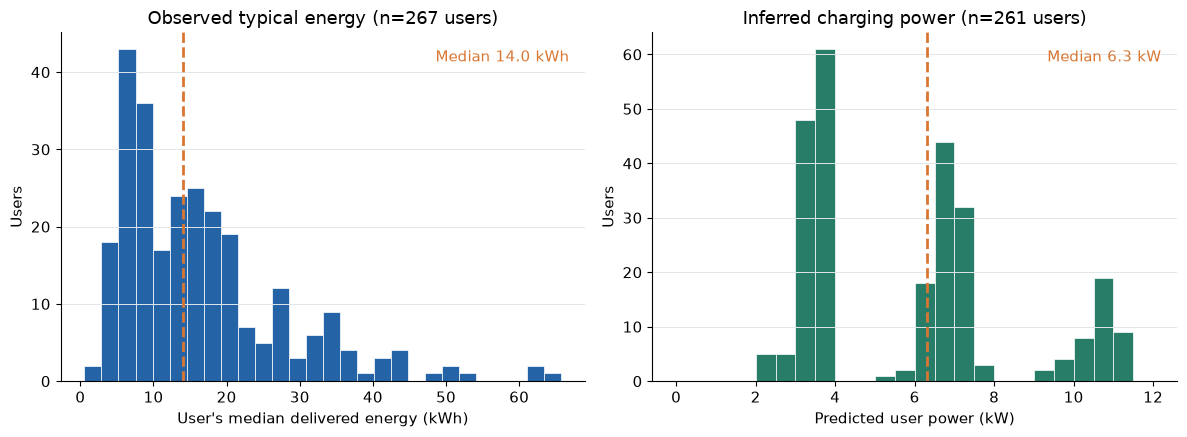

- **Observed:** user medians range from 7.9 to 20.7 kWh across the middle half of users; the median user has 77 recorded sessions.
- **Inferred:** median D2 charging power is 6.3 kW. Its shape reflects the authors' estimation method and site equipment constraints, not directly observed instantaneous power.

In [6]:
user_summary = d1.groupby("user_id").agg(
    sessions=("session_id","size"), median_energy_kwh=("energy_session","median"),
    mean_energy_kwh=("energy_session","mean"), location=("location","first"))
predicted_power = d2.charging_power.dropna()
predicted_capacity = d2.battery_capacity.dropna()
user_stats = pd.DataFrame({
    "Recorded sessions per user":describe_quantity(user_summary.sessions,"count"),
    "User median delivered energy":describe_quantity(user_summary.median_energy_kwh,"kWh"),
    "Predicted user charging power":describe_quantity(predicted_power,"kW"),
    "Predicted net battery capacity":describe_quantity(predicted_capacity,"kWh"),
}).T
display(user_stats.round(2))
fig,axes=plt.subplots(1,2,figsize=(12.0,4.5))
axes[0].hist(user_summary.median_energy_kwh,bins=28,color=BLUE,edgecolor="white",linewidth=.5)
axes[0].axvline(user_summary.median_energy_kwh.median(),color=ORANGE,ls="--",lw=2)
axes[0].text(.97,.95,f"Median {user_summary.median_energy_kwh.median():.1f} kWh",
             transform=axes[0].transAxes,ha="right",va="top",color=ORANGE)
axes[0].set(title=f"Observed typical energy (n={len(user_summary)} users)",
            xlabel="User's median delivered energy (kWh)",ylabel="Users")
axes[1].hist(predicted_power,bins=np.arange(0,12.1,.5),color=GREEN,
             edgecolor="white",linewidth=.5)
axes[1].axvline(predicted_power.median(),color=ORANGE,ls="--",lw=2)
axes[1].text(.97,.95,f"Median {predicted_power.median():.1f} kW",
             transform=axes[1].transAxes,ha="right",va="top",color=ORANGE)
axes[1].set(title=f"Inferred charging power (n={len(predicted_power)} users)",
            xlabel="Predicted user power (kW)",ylabel="Users")
for ax in axes:
    ax.grid(axis="y",color="#e1e6eb",lw=.7)
fig_users=save_show(fig,"03_user_variation_and_predicted_power.png")
display(Markdown(
    f"- **Observed:** user medians range from "
    f"{user_summary.median_energy_kwh.quantile(.25):.1f} to "
    f"{user_summary.median_energy_kwh.quantile(.75):.1f} kWh across the middle half of users; "
    f"the median user has {user_summary.sessions.median():.0f} recorded sessions.\n"
    f"- **Inferred:** median D2 charging power is {predicted_power.median():.1f} kW. "
    "Its shape reflects the authors' estimation method and site equipment constraints, "
    "not directly observed instantaneous power."
))



In [7]:
modeled_stats = pd.DataFrame({
    "Calculated active charging duration":describe_quantity(d3.charging_time,"h"),
    "Calculated idle duration":describe_quantity(d3.idle_time,"h"),
    "Predicted plug-in SoC":describe_quantity(d3.SoC_start,"%"),
}).T
display(modeled_stats.round(2))
display(pd.Series({
    "D3 sessions with predicted charging/idle time":int(d3.charging_time.notna().sum()),
    "D3 sessions with calculated idle >1 h":int(d3.idle_time.gt(1).sum()),
    "D3 sessions classified non-flexible by modeled idle <1 h":int(d3.non_flex_session.notna().sum()),
    "D4 modeled charging-hour rows with energy value":int(d4.energy_charged_i.notna().sum()),
},name="Prediction-layer coverage"))
display(Markdown(
    "`charging_time = energy_session / predicted charging_power`, and "
    "`idle_time = connection_time - charging_time` (paper pp. 6–7). The authors "
    "assume charging starts immediately at plug-in and use a 95% final SoC for "
    "their SoC reconstruction. These values can inform sensitivity checks, "
    "but do not independently validate actual active charging time or plug-in SoC."
))



,n,unit,mean,p25,median,p75,p90
Calculated active charging duration,34358,h,2.650063,1.161092,2.086903,3.475483,5.226758
Calculated idle duration,34358,h,9.866262,1.034452,7.665776,13.181095,19.31886
Predicted plug-in SoC,34537,%,58.631038,40.982659,61.701627,78.08187,86.826469


D3 sessions with predicted charging/idle time                34358
D3 sessions with calculated idle >1 h                        25862
D3 sessions classified non-flexible by modeled idle <1 h      8496
D4 modeled charging-hour rows with energy value             125673
Name: Prediction-layer coverage, dtype: int64

`charging_time = energy_session / predicted charging_power`, and `idle_time = connection_time - charging_time` (paper pp. 6–7). The authors assume charging starts immediately at plug-in and use a 95% final SoC for their SoC reconstruction. These values can inform sensitivity checks, but do not independently validate actual active charging time or plug-in SoC.

## Key findings for the later mobility-to-charging stage

Each row distinguishes a direct charging-report result from an assumption-based
prediction. The table is calculated from the four raw CSVs each time the
notebook runs. These observations concern sampled residential charge points.

In [8]:
findings = pd.DataFrame([
    (f"{len(d1):,} reports; {d1.user_id.nunique()} users; {d1.location.nunique()} sites",
     "Original residential charging reports", "Defines the empirical setting; no workplace/public transfer without evidence"),
    (f"{plugin_evening:.1f}% plug in 16:00–21:59; {plugout_morning:.1f}% unplug 06:00–09:59",
     "Original timestamps, local clock", "Check residential connection timing"),
    (f"{overnight:.1f}% span a local midnight among {len(complete):,} complete sessions",
     "Original plug-in/plug-out timestamps", "Check overnight connection prevalence"),
    (f"Energy: median {d1.energy_session.median():.1f} kWh; p90 {d1.energy_session.quantile(.9):.1f} kWh",
     "Delivered charging energy from reports", "Check residential energy per modeled session"),
    (f"Connection: median {d1.connection_time.median():.1f} h; p90 {d1.connection_time.quantile(.9):.1f} h",
     "Duration calculated in original reports", "Check modeled connection windows"),
    (f"User median energy IQR {user_summary.median_energy_kwh.quantile(.25):.1f}–{user_summary.median_energy_kwh.quantile(.75):.1f} kWh",
     "Between-user variation in observed energy", "Check heterogeneity without equating users to sessions"),
    (f"Predicted power median {predicted_power.median():.1f} kW; capacity median {predicted_capacity.median():.1f} kWh",
     "Authors' user-level predictions", "Scenario inputs only; not measured hardware"),
    (f"Calculated charge time median {d3.charging_time.median():.1f} h; plug-in SoC median {d3.SoC_start.median():.1f}%",
     "Authors' model using predicted power/capacity and SoC assumptions", "Sensitivity checks only; not telemetry"),
],columns=["Numerical result","Provenance","Potential later use"])
display(findings)



,Numerical result,Provenance,Potential later use
0,"35,377 reports; 267 users; 12 sites",Original residential charging reports,Defines the empirical setting; no workplace/pu...
1,52.1% plug in 16:00–21:59; 34.1% unplug 06:00–...,"Original timestamps, local clock",Check residential connection timing
2,"59.7% span a local midnight among 35,339 compl...",Original plug-in/plug-out timestamps,Check overnight connection prevalence
3,Energy: median 9.0 kWh; p90 26.8 kWh,Delivered charging energy from reports,Check residential energy per modeled session
4,Connection: median 11.2 h; p90 22.1 h,Duration calculated in original reports,Check modeled connection windows
5,User median energy IQR 7.9–20.7 kWh,Between-user variation in observed energy,Check heterogeneity without equating users to ...
6,Predicted power median 6.3 kW; capacity median...,Authors' user-level predictions,Scenario inputs only; not measured hardware
7,Calculated charge time median 2.1 h; plug-in S...,Authors' model using predicted power/capacity ...,Sensitivity checks only; not telemetry


## Limits and reproducibility

- D1 has 38 sessions without a plug-out/duration; every statistic uses its
  available denominator. No additional observations were discarded.
- The location coverage and observation windows differ. Per-user counts are
  counts *in these reports*, not a comparable weekly charging frequency.
- Original delivered energy is charging-point energy. Battery energy and SoC
  need separate assumptions; the D2–D4 estimates are not measurement truth.
- D4 contains 6,710 zero-connected-capacity rows without user/session IDs.
  They cannot be joined to an identifiable session and are excluded from joins.
- The site sample contains residential/shared residential charging only.
  Neither workplace nor public charging behaviour is measured here.
- The notebook recalculates and saves all Norway figures from the four raw CSVs.

In [9]:
print(f"DATA: D1 {d1.shape[0]:,}x7; D2 {d2.shape[0]}x3; D3 {d3.shape[0]:,}x8; D4 {d4.shape[0]:,}x9")
print(f"EVENTS: {plugin_evening:.1f}% plug in 16:00–21:59; {plugout_morning:.1f}% unplug 06:00–09:59; "
      f"{overnight:.1f}% of complete sessions cross local midnight")
print(f"OBSERVED: energy median {d1.energy_session.median():.1f} kWh, p90 {d1.energy_session.quantile(.9):.1f}; "
      f"connection median {d1.connection_time.median():.1f} h, p90 {d1.connection_time.quantile(.9):.1f}")
print(f"USERS: median {user_summary.sessions.median():.0f} recorded sessions/user; "
      f"user median energy IQR {user_summary.median_energy_kwh.quantile(.25):.1f}–"
      f"{user_summary.median_energy_kwh.quantile(.75):.1f} kWh")
print(f"INFERRED: power median {predicted_power.median():.1f} kW; "
      f"calculated charging time median {d3.charging_time.median():.1f} h; "
      f"predicted plug-in SoC median {d3.SoC_start.median():.1f}%")
print("FIGURES:")
for path in [fig_time,fig_energy,fig_users]:
    print(" -",path.relative_to(root).as_posix())


DATA: D1 35,377x7; D2 267x3; D3 34,537x8; D4 469,897x9
EVENTS: 52.1% plug in 16:00–21:59; 34.1% unplug 06:00–09:59; 59.7% of complete sessions cross local midnight
OBSERVED: energy median 9.0 kWh, p90 26.8; connection median 11.2 h, p90 22.1
USERS: median 77 recorded sessions/user; user median energy IQR 7.9–20.7 kWh
INFERRED: power median 6.3 kW; calculated charging time median 2.1 h; predicted plug-in SoC median 61.7%
FIGURES:
 - outputs/figures/norway_ev/01_plugin_plugout_clock.png
 - outputs/figures/norway_ev/02_energy_and_connection_duration.png
 - outputs/figures/norway_ev/03_user_variation_and_predicted_power.png
